# MEA-CO2 水系: 反応物・TS・生成物エネルギー解析
反応物 (R)、遷移状態 (TS)、生成物 (P) の電子エネルギーを読み取り、相対エネルギーと活性化エネルギーを計算・可視化します。


In [1]:
from pathlib import Path

# プロジェクトルートと分析ディレクトリ
project_root = Path("/home/yamamoto/Work/chemistry/orca-work/MEA_CO2_water_afify")
analysis_dir = project_root / "analysis"
analysis_dir.mkdir(parents=True, exist_ok=True)

# 既定ログファイルパス
reactant_log = project_root / "forwardopt" / "forward_opt.log"
ts_log = project_root / "tsopt" / "tsopt_freq.log"
product_log = project_root / "backwardopt" / "backward_opt.log"
files = {"R": reactant_log, "TS": ts_log, "P": product_log}
files

{'R': PosixPath('/home/yamamoto/Work/chemistry/orca-work/MEA_CO2_water_afify/forwardopt/forward_opt.log'),
 'TS': PosixPath('/home/yamamoto/Work/chemistry/orca-work/MEA_CO2_water_afify/tsopt/tsopt_freq.log'),
 'P': PosixPath('/home/yamamoto/Work/chemistry/orca-work/MEA_CO2_water_afify/backwardopt/backward_opt.log')}

In [ ]:
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(
    context="notebook", style="whitegrid", font="DejaVu Sans", rc={"figure.dpi": 150}
)

In [ ]:
def extract_energy_from_text(text: str) -> float | None:
    """Extract the last FINAL SINGLE POINT ENERGY value in Eh."""
    matches = re.findall(r"FINAL\s+SINGLE\s+POINT\s+ENERGY\s+([\-\d\.]+)", text)
    return float(matches[-1]) if matches else None


def extract_energy_from_csv(path: Path) -> float | None:
    if not path.exists():
        return None
    try:
        df = pd.read_csv(path)
    except Exception:
        return None
    for col in ["E_elec", "energy", "E", "total_energy"]:
        if col in df.columns:
            return float(df[col].iloc[-1])
    return None


def extract_energy_from_json(path: Path) -> float | None:
    if not path.exists():
        return None
    try:
        data = json.loads(path.read_text())
    except Exception:
        return None
    if isinstance(data, dict):
        for key in ["E_elec", "energy", "total_energy"]:
            if key in data:
                return float(data[key])
    return None


def extract_energy(path: Path) -> float:
    if path.suffix.lower() == ".csv":
        val = extract_energy_from_csv(path)
    elif path.suffix.lower() == ".json":
        val = extract_energy_from_json(path)
    else:
        text = path.read_text(encoding="utf-8", errors="ignore")
        val = extract_energy_from_text(text)
    if val is None:
        raise ValueError(f"Energy not found in {path}")
    return val

In [ ]:
def extract_corrections(text: str) -> dict:
    """Extract ZPE/Hcorr/Gcorr if present. Returns Eh values or None."""

    def grab(pattern):
        m = re.search(pattern, text)
        if not m:
            return None
        try:
            return float(m.group(1))
        except ValueError:
            return None

    zpe = grab(r"Zero\s*Point\s*Energy\s*[:=]\s*([\-\d\.]+)") or grab(
        r"Zero point energy\s+([\-\d\.]+)"
    )
    hcorr = grab(r"Thermal Enthalpy\s*correction\s*[:=]\s*([\-\d\.]+)") or grab(
        r"H\(Thermal\)\s*=\s*([\-\d\.]+)"
    )
    gcorr = grab(r"Thermal Free Energy\s*correction\s*[:=]\s*([\-\d\.]+)") or grab(
        r"G\(Thermal\)\s*=\s*([\-\d\.]+)"
    )
    return {"ZPE": zpe, "Hcorr": hcorr, "Gcorr": gcorr}

In [7]:
records = []
for state, path in files.items():
    text = path.read_text(encoding="utf-8", errors="ignore")
    E_elec = extract_energy(path)
    corr = extract_corrections(text)
    records.append(
        {
            "state": state,
            "path": str(path),
            "E_elec_Eh": E_elec,
            "ZPE_Eh": corr["ZPE"],
            "Hcorr_Eh": corr["Hcorr"],
            "Gcorr_Eh": corr["Gcorr"],
        }
    )

energies = pd.DataFrame(records).set_index("state")
energies

,path,E_elec_Eh,ZPE_Eh,Hcorr_Eh,Gcorr_Eh
state,,,,,
R,/home/yamamoto/Work/chemistry/orca-work/MEA_CO...,-399.093499,None,None,None
TS,/home/yamamoto/Work/chemistry/orca-work/MEA_CO...,-399.088476,None,None,None
P,/home/yamamoto/Work/chemistry/orca-work/MEA_CO...,-399.092090,None,None,None


In [ ]:
Eh_to_kJmol = 2625.49962
Eh_to_kcalmol = 627.509474


def add_converted(df: pd.DataFrame, col: str) -> pd.DataFrame:
    df[f"{col}_kJmol"] = df[col] * Eh_to_kJmol
    df[f"{col}_kcalmol"] = df[col] * Eh_to_kcalmol
    return df

In [9]:
energies["E_ZPE_Eh"] = energies["E_elec_Eh"] + energies["ZPE_Eh"].fillna(0)
energies["G_Eh"] = energies["E_elec_Eh"] + energies["Gcorr_Eh"].fillna(0)

add_converted(energies, "E_elec_Eh")
add_converted(energies, "E_ZPE_Eh")
add_converted(energies, "G_Eh")
energies

/tmp/ipykernel_269898/3026292223.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  energies['E_ZPE_Eh'] = energies['E_elec_Eh'] + energies['ZPE_Eh'].fillna(0)
/tmp/ipykernel_269898/3026292223.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  energies['G_Eh'] = energies['E_elec_Eh'] + energies['Gcorr_Eh'].fillna(0)


,path,E_elec_Eh,ZPE_Eh,Hcorr_Eh,Gcorr_Eh,E_ZPE_Eh,G_Eh,E_elec_Eh_kJmol,E_elec_Eh_kcalmol,E_ZPE_Eh_kJmol,E_ZPE_Eh_kcalmol,G_Eh_kJmol,G_Eh_kcalmol
state,,,,,,,,,,,,,
R,/home/yamamoto/Work/chemistry/orca-work/MEA_CO...,-399.093499,None,None,None,-399.093499,-399.093499,-1.047820e+06,-250434.951373,-1.047820e+06,-250434.951373,-1.047820e+06,-250434.951373
TS,/home/yamamoto/Work/chemistry/orca-work/MEA_CO...,-399.088476,None,None,None,-399.088476,-399.088476,-1.047807e+06,-250431.799420,-1.047807e+06,-250431.799420,-1.047807e+06,-250431.799420
P,/home/yamamoto/Work/chemistry/orca-work/MEA_CO...,-399.092090,None,None,None,-399.092090,-399.092090,-1.047816e+06,-250434.067433,-1.047816e+06,-250434.067433,-1.047816e+06,-250434.067433


In [10]:
def delta(relative_to: str, col: str) -> pd.Series:
    ref = energies.loc[relative_to, col]
    return energies[col] - ref


summary = pd.DataFrame(index=energies.index)
summary["dE_Eh"] = delta("R", "E_elec_Eh")
summary["dE_ZPE_Eh"] = delta("R", "E_ZPE_Eh")
summary["dG_Eh"] = delta("R", "G_Eh")
add_converted(summary, "dE_Eh")
add_converted(summary, "dE_ZPE_Eh")
add_converted(summary, "dG_Eh")

# 活性化・反応エネルギー
metrics = {
    "Ea_Eh": summary.loc["TS", "dE_Eh"],
    "Ea_kJmol": summary.loc["TS", "dE_Eh_kJmol"],
    "dE_rxn_Eh": summary.loc["P", "dE_Eh"],
    "dE_rxn_kJmol": summary.loc["P", "dE_Eh_kJmol"],
}
metrics

{'Ea_Eh': np.float64(0.005022955735967116),
 'Ea_kJmol': np.float64(13.187768376058484),
 'dE_rxn_Eh': np.float64(0.0014086480109654076),
 'dE_rxn_kJmol': np.float64(3.6984048175034334)}

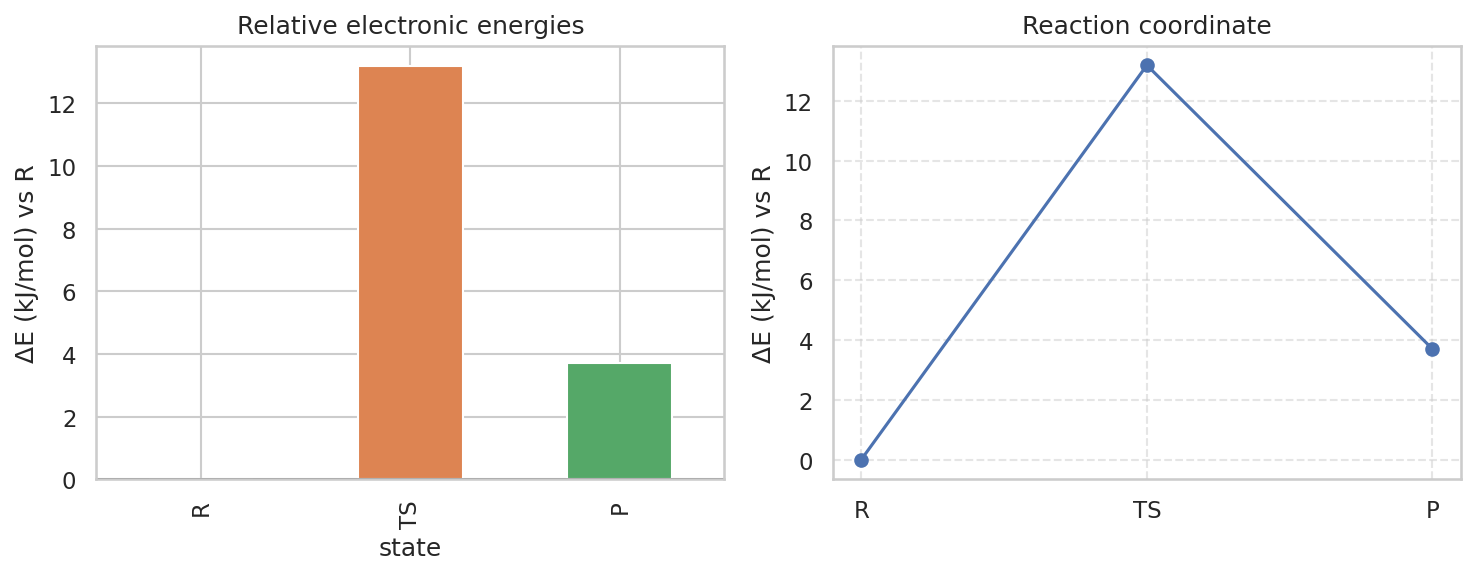

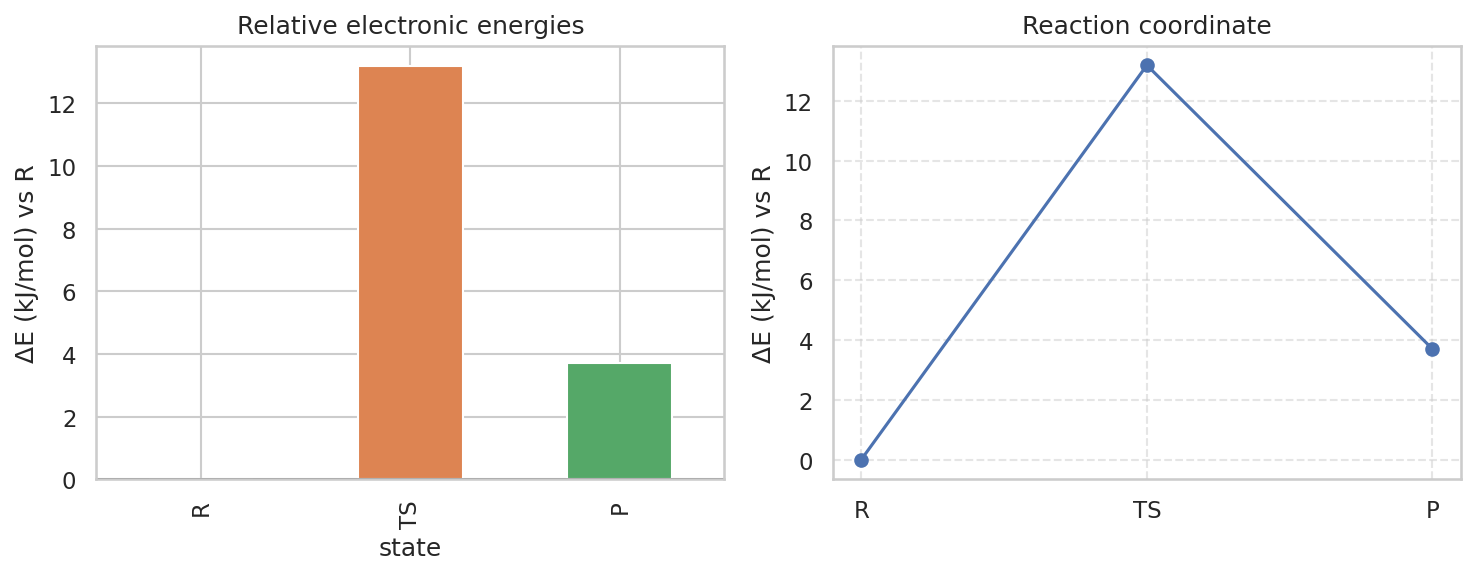

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Bar: electronic energies relative
summary.loc[["R", "TS", "P"], "dE_Eh_kJmol"].plot(
    kind="bar", ax=ax[0], color=["C0", "C1", "C2"]
)
ax[0].set_ylabel("ΔE (kJ/mol) vs R")
ax[0].set_title("Relative electronic energies")
ax[0].axhline(0, color="k", linewidth=0.8)

# Reaction coordinate plot
states_order = ["R", "TS", "P"]
ax[1].plot(states_order, summary.loc[states_order, "dE_Eh_kJmol"], marker="o")
ax[1].set_ylabel("ΔE (kJ/mol) vs R")
ax[1].set_title("Reaction coordinate")
ax[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
bars_path = analysis_dir / "energy_bars.png"
rc_path = analysis_dir / "reaction_coordinate.png"
fig.savefig(bars_path)
plt.savefig(rc_path)
fig

In [ ]:
# Basic sanity checks
assert "E_elec_Eh" in energies.columns, "E_elec_Eh missing"
assert (
    energies.loc["TS", "E_elec_Eh"] > energies.loc["R", "E_elec_Eh"]
), "TS energy should be higher than R (electronic)"

# Relative energies positivity for barrier
assert summary.loc["TS", "dE_Eh_kJmol"] > 0, "Activation energy should be positive"
summary[["dE_Eh_kJmol", "dE_ZPE_Eh_kJmol", "dG_Eh_kJmol"]]

In [12]:
summary_csv = analysis_dir / "energy_summary.csv"
energies.to_csv(summary_csv)

print("Energies (Eh):")
print(energies[["E_elec_Eh", "E_ZPE_Eh", "G_Eh"]])

print("\nRelative energies vs Reactant (kJ/mol):")
print(summary[["dE_Eh_kJmol", "dE_ZPE_Eh_kJmol", "dG_Eh_kJmol"]])

print("\nKey metrics:")
print(f"Activation energy ΔE‡ = {metrics['Ea_kJmol']:.2f} kJ/mol")
print(f"Reaction energy ΔE_rxn = {metrics['dE_rxn_kJmol']:.2f} kJ/mol")

summary

Energies (Eh):
        E_elec_Eh    E_ZPE_Eh        G_Eh
state                                    
R     -399.093499 -399.093499 -399.093499
TS    -399.088476 -399.088476 -399.088476
P     -399.092090 -399.092090 -399.092090

Relative energies vs Reactant (kJ/mol):
       dE_Eh_kJmol  dE_ZPE_Eh_kJmol  dG_Eh_kJmol
state                                           
R         0.000000         0.000000     0.000000
TS       13.187768        13.187768    13.187768
P         3.698405         3.698405     3.698405

Key metrics:
Activation energy ΔE‡ = 13.19 kJ/mol
Reaction energy ΔE_rxn = 3.70 kJ/mol


,dE_Eh,dE_ZPE_Eh,dG_Eh,dE_Eh_kJmol,dE_Eh_kcalmol,dE_ZPE_Eh_kJmol,dE_ZPE_Eh_kcalmol,dG_Eh_kJmol,dG_Eh_kcalmol
state,,,,,,,,,
R,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
TS,0.005023,0.005023,0.005023,13.187768,3.151952,13.187768,3.151952,13.187768,3.151952
P,0.001409,0.001409,0.001409,3.698405,0.883940,3.698405,0.883940,3.698405,0.883940
